# **Polynomial Regression. Model Complexity. Regularisation. Logistic Regression**

In previous lecture we studied the basics of linear regression, gradient descent and importance of feature scaling. Today we continue with more advanced type of linear regression.

Let's consider the following example:

## Non-linear data: polynomial regression

We generate a set of points $(x_i, y_i)$, where $x_i$ are uniformly distributed on $[-2, 2]$,
and $y_i$ lie along a piecewise-linear curve in the shape of the letter **M** with Gaussian noise:

$$y_i = f(x_i) + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0, \sigma^2),$$

$$
f(x) =
\begin{cases}
x + 2,        & x < -1, \\
-0.7x + 0.3,  & -1 \le x < 0, \\
\;\;\,0.7x + 0.3,  & 0 \le x < 1, \\
-x + 2,       & x \ge 1.
\end{cases}
$$

We then approximate this data using three models of different complexity to demonstrate
**underfitting** (a straight line and a parabola) and **overfitting** (a high-degree polynomial).

### Polynomial relationship between features: how can it be incorporated into linear regression?

Ordinary linear regression models the relationship as:

$$\hat{y} = w_0 + w_1 x$$

However, if there is a **nonlinear (polynomial) relationship** between the feature $x$ and the target variable $y$, we can expand the feature space by adding powers of $x$:

$$\hat{y} = w_0 + w_1 x + w_2 x^2 + w_3 x^3 + \dots + w_d x^d$$

The key idea is: **this model remains linear with respect to the parameters** $w_0, w_1, \dots, w_d$.
We simply create new features:

$$\mathbf{x}' = \begin{bmatrix} x \\ x^2 \\ x^3 \\ \vdots \\ x^d \end{bmatrix}$$

and apply ordinary linear regression to the expanded feature vector $\mathbf{x}'$:

$$\hat{y} = w_0 + \mathbf{w}^T \mathbf{x}'$$

In other words, **polynomial regression is ordinary linear regression, but with polynomially
transformed features**. In `sklearn`, this is done using `PolynomialFeatures(degree=d)`,
which automatically generates all powers (and products) of the features up to degree $d$.

> **Danger of overfitting:** As $d$ increases, the model becomes more flexible and passes
> almost through every data point, but loses its ability to generalize — it memorizes the
> noise instead of the underlying pattern (see the degree=15 plot).

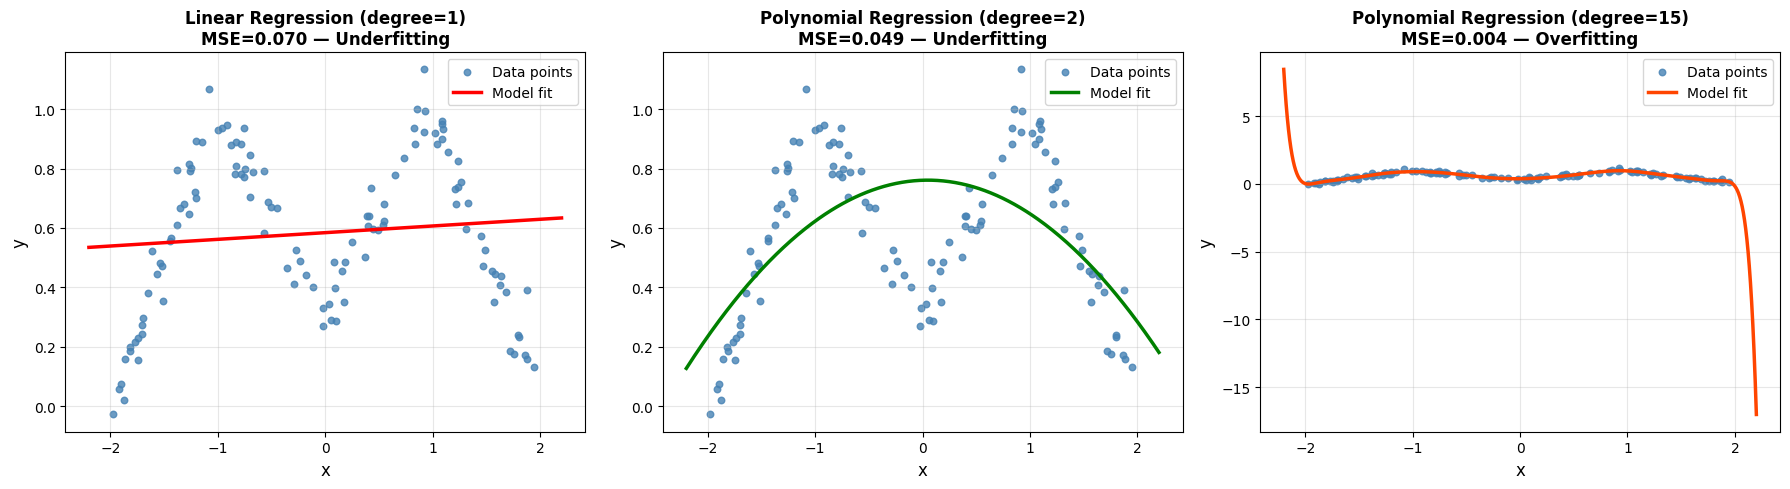

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

np.random.seed(42)
n_samples = 120
X = np.sort(np.random.uniform(-2, 2, n_samples))

def m_shape(t):
    return np.piecewise(
        t,
        [t < -1, (t >= -1) & (t < 0), (t >= 0) & (t < 1), t >= 1],
        [lambda s: s + 2,
         lambda s: -0.7*s + 0.3,
         lambda s:  0.7*s + 0.3,
         lambda s: -s + 2]
    )

y = m_shape(X) + np.random.normal(0, 0.07, n_samples)
X_col = X.reshape(-1, 1)

X_grid = np.linspace(-2.2, 2.2, 400).reshape(-1, 1)

def poly_fit(degree):
    poly = PolynomialFeatures(degree=degree)
    Xp = poly.fit_transform(X_col)
    model = LinearRegression().fit(Xp, y)
    mse = mean_squared_error(y, model.predict(Xp))
    return model.predict(poly.transform(X_grid)), mse

y_pred1,  mse1  = poly_fit(1)
y_pred2,  mse2  = poly_fit(2)
y_pred15, mse15 = poly_fit(15)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

configs = [
    (y_pred1,  f"Linear Regression (degree=1)\nMSE={mse1:.3f} — Underfitting", "red"),
    (y_pred2,  f"Polynomial Regression (degree=2)\nMSE={mse2:.3f} — Underfitting", "green"),
    (y_pred15, f"Polynomial Regression (degree=15)\nMSE={mse15:.3f} — Overfitting", "orangered"),
]

for ax, (y_pred, title, color) in zip(axes, configs):
    ax.scatter(X, y, s=22, color="steelblue", alpha=0.8, label="Data points")
    ax.plot(X_grid, y_pred, color=color, linewidth=2.5, label="Model fit")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("x", fontsize=12)
    ax.set_ylabel("y", fontsize=12)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

## The importance of validation set in case of understanding model complexity


Training error is tricky: in can monotonically decrease with the increase of model complexity, and for $d=15$ model curve catch  **all** blue dots, i.e, the model remembers a noise,
$MSE_{train}\approx 0$. Validation set, which is not seen by the model during the training, often reveals the whole picture:

$$MSE_{train}=\frac{1}{n_{tr}}\sum_{i=1}^{n_{tr}}(y_i-\hat y_i)^2,\qquad
MSE_{val}=\frac{1}{n_{val}}\sum_{j=1}^{n_{val}}(y_j-\hat y_j)^2$$


Це bias–variance tradeoff:

$$\mathbb{E}(\,MSE_{val})\approx\underbrace{\mathrm{Bias}^2}_{\text{too simple}}+
\underbrace{\mathrm{Variance}}_{\text{noise sensitivity}}+\sigma^2$$

Polynomial regression is parameters linear : $\hat y=w_0+\mathbf w^T\mathbf x'$,
where $\mathbf x'=[x,\,x^2,\,\dots,\,x^d]^T$ (`PolynomialFeatures`).
Power $d$ is the hyperparameter, which can be chosed based on validation:
$d^{*}=\arg\min_d\,MSE_{val}$.

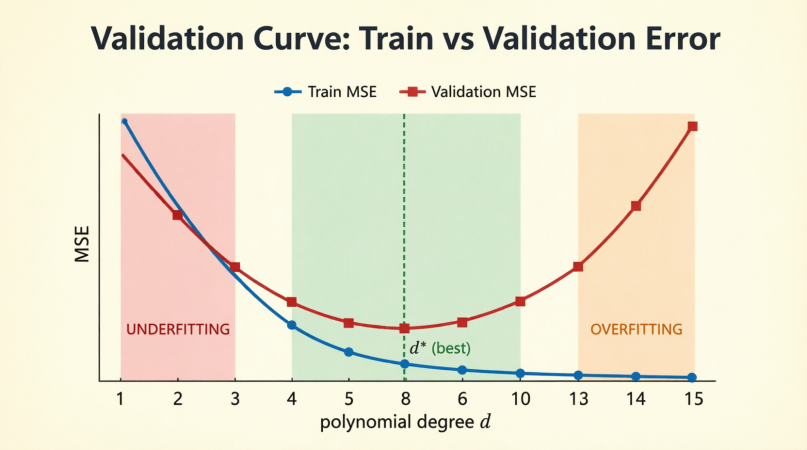

## Bias–Variance Trade-off in Machine Learning

Machine learning models are affected by two main sources of error: **bias** and **variance**.

*  **Bias** occurs when a model is too simple to learn the main patterns in the data. Such a model may fail to represent the true relationship between the variables, resulting in underfitting.

*  **Variance** occurs when a model is too complex and depends too much on the training data. It may learn both the actual patterns and random noise in the data. As a result, the model can perform well on training data but poorly on new data. This is known as overfitting.

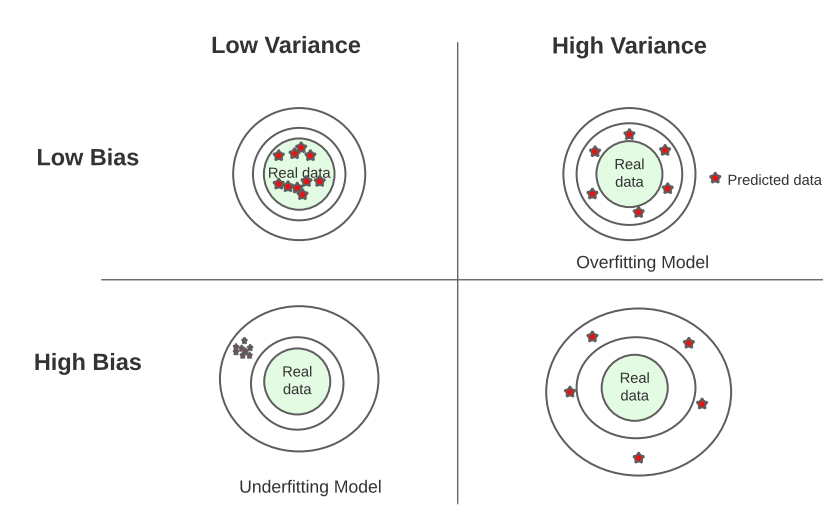

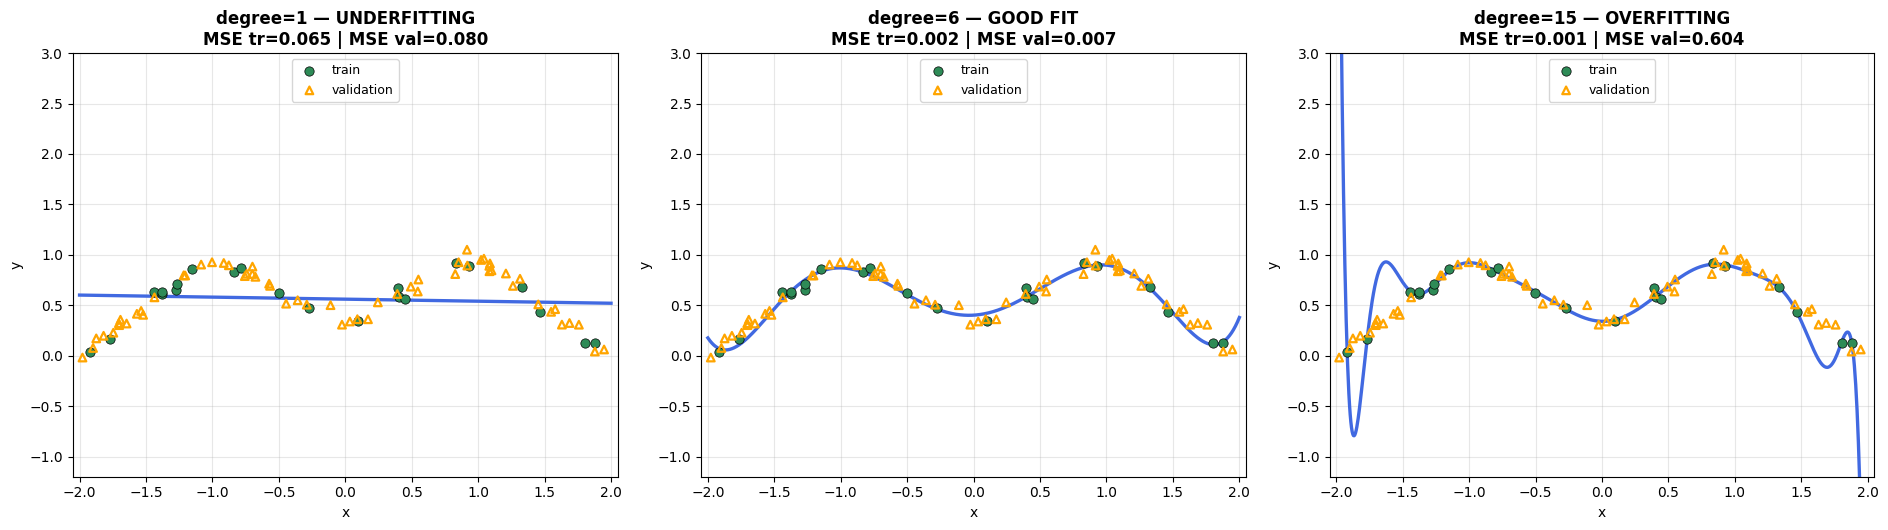

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

np.random.seed(42)

C_CURVE = "royalblue"
C_TRAIN = "seagreen"
C_VAL   = "orange"

def m_shape(t):
    return np.piecewise(
        t,
        [t < -1, (t >= -1) & (t < 0), (t >= 0) & (t < 1), t >= 1],
        [lambda s: s + 2,
         lambda s: -0.7*s + 0.3,
         lambda s:  0.7*s + 0.3,
         lambda s: -s + 2]
    )

n_train, n_val = 22, 60
X_tr  = np.sort(np.random.uniform(-2, 2, n_train))
y_tr  = m_shape(X_tr)  + np.random.normal(0, 0.05, n_train)
X_val = np.sort(np.random.uniform(-2, 2, n_val))
y_val = m_shape(X_val) + np.random.normal(0, 0.05, n_val)
X_tr_c, X_val_c = X_tr.reshape(-1, 1), X_val.reshape(-1, 1)

grid = np.linspace(-2, 2, 800).reshape(-1, 1)

def fit_predict(degree):
    poly = PolynomialFeatures(degree)
    m = LinearRegression().fit(poly.fit_transform(X_tr_c), y_tr)
    return (m.predict(poly.transform(X_tr_c)),
            m.predict(poly.transform(X_val_c)),
            m.predict(poly.transform(grid)))

p_tr1, p_val1, g1 = fit_predict(1)
p_tr6, p_val6, g6 = fit_predict(6)
p_trN, p_valN, gN = fit_predict(15)

fig, axes = plt.subplots(1, 3, figsize=(19, 5.4))

panels = [
    ("degree=1 — UNDERFITTING",        g1, p_tr1, p_val1),
    ("degree=6 — GOOD FIT",            g6, p_tr6, p_val6),
    (f"degree={15} — OVERFITTING", gN, p_trN, p_valN),
]

for ax, (title, g, p_tr, p_val) in zip(axes, panels):
    ax.scatter(X_tr, y_tr, s=45, color=C_TRAIN, edgecolors="k",Regularization
               lw=.5, label="train", zorder=3)
    ax.scatter(X_val, y_val, s=30, marker="^", facecolors="none",
               edgecolors=C_VAL, lw=1.6, label="validation", zorder=3)
    ax.plot(grid, g, color=C_CURVE, lw=2.4, zorder=2)
    ax.set_title(f"{title}\nMSE tr={mean_squared_error(y_tr, p_tr):.3f} | "
                 f"MSE val={mean_squared_error(y_val, p_val):.3f}",
                 fontsize=12, fontweight="bold")
    ax.set_xlim(-2.05, 2.05)
    ax.set_ylim(-1.2, 3.0)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.grid(alpha=.3); ax.legend(fontsize=9, loc="upper center")

plt.tight_layout()
plt.show()

**Colors:** model (line/curve) — **blue**, train — **green**,
validation — **orange**.

| Regime | Fit (blue) | $MSE_{train}$ | $MSE_{val}$ |
|---|---|---|---|
| **Underfitting**, $d=1$ | the line fits quiet bad | high | high |
| **Good fit**, $d=6$ | smooth curve ± fits train and val | moderate | **minimal** |
| **Overfitting**, $d=n_{tr}-1$ | fits **each** green dot, but struggles to fit orange | $\approx 0$ | high |

In real world scenarious there are a multiple approaches to solve **overfitting** problem. In addition to searching the optimal hyper-parameters, there are well-known methods called **Regularisation**.   

## Regularisation: Ridge and Lasso vs. Overfitting

**Concept.** A degree-15 polynomial can bend through every noisy point, but to do
that it needs huge coefficients. Regularization adds a *penalty for large
weights* to the loss, so the model prefers smoother curves.

### Ridge regression (L2 penalty)

$$J_{\text{Ridge}}(\mathbf w)=
\underbrace{\sum_{i=1}^{n}(y_i-\hat y_i)^2}_{\text{fit to the data}}+
\;\lambda\;\underbrace{\sum_{j=1}^{d}w_j^2}_{\text{penalty for large weights}}$$

Terms explained:

- $y_i$ — the observed value, $\hat y_i$ — the model's prediction for point $i$;
  the first sum is just the usual squared error (the same loss as in ordinary
  regression);
- $w_j$ — the model's coefficients (weights), e.g. the weights in front of
  $x,\;x^2,\;\dots,\;x^{15}$;
- $n$ — number of samples, $d$ — number of features;
- $\lambda \ge 0$ — the **regularization strength** (called `alpha` in sklearn):
  - $\lambda = 0$ → ordinary polynomial regression (overfitting);
  - larger $\lambda$ → weights are shrunk more → the curve becomes smoother;
  - too large $\lambda$ → the model is squeezed too much (underfitting).

Because the penalty uses $w_j^2$, a big weight is punished *very* strongly, so no
single coefficient can explode. Ridge shrinks all weights toward zero but keeps
all of them nonzero.

### Lasso regression (L1 penalty)

$$J_{\text{Lasso}}(\mathbf w)=
\sum_{i=1}^{n}(y_i-\hat y_i)^2+\;\lambda\sum_{j=1}^{d}|w_j|$$

The loss is the same, but the penalty uses the **absolute value** $|w_j|$
instead of $w_j^2$. This small change has a big effect: some weights become
**exactly zero**. So Lasso automatically *drops useless features*, for example,
it can throw away $x^{10},\dots,x^{15}$ and keep only a few useful powers of $x$.

### How we use them in the code

- We pick $\lambda$ on the **validation set** (the one with the smaller
  $MSE_{val}$ wins), never on the training set.
- We standardize the features first (`StandardScaler`), because the penalty
  "looks" at the size of the weights, and $x^{15}$ lives on a very different
  scale than $x$.

| Method | Penalty | What happens to the weights |
|---|---|---|
| Ridge | $\lambda\sum_j w_j^2$ | all become small, none become exactly zero |
| Lasso | $\lambda\sum_j \lvert w_j\rvert$ | many become exactly zero → feature selection |

Need both sparsity and stability with correlated features? Use **ElasticNet**:
   $J=\|y-X\mathbf w\|_2^2+\lambda_1\|\mathbf w\|_1+\lambda_2\|\mathbf w\|_2^2$.

lambda* Ridge = 0.010 | lambda* Lasso = 0.010


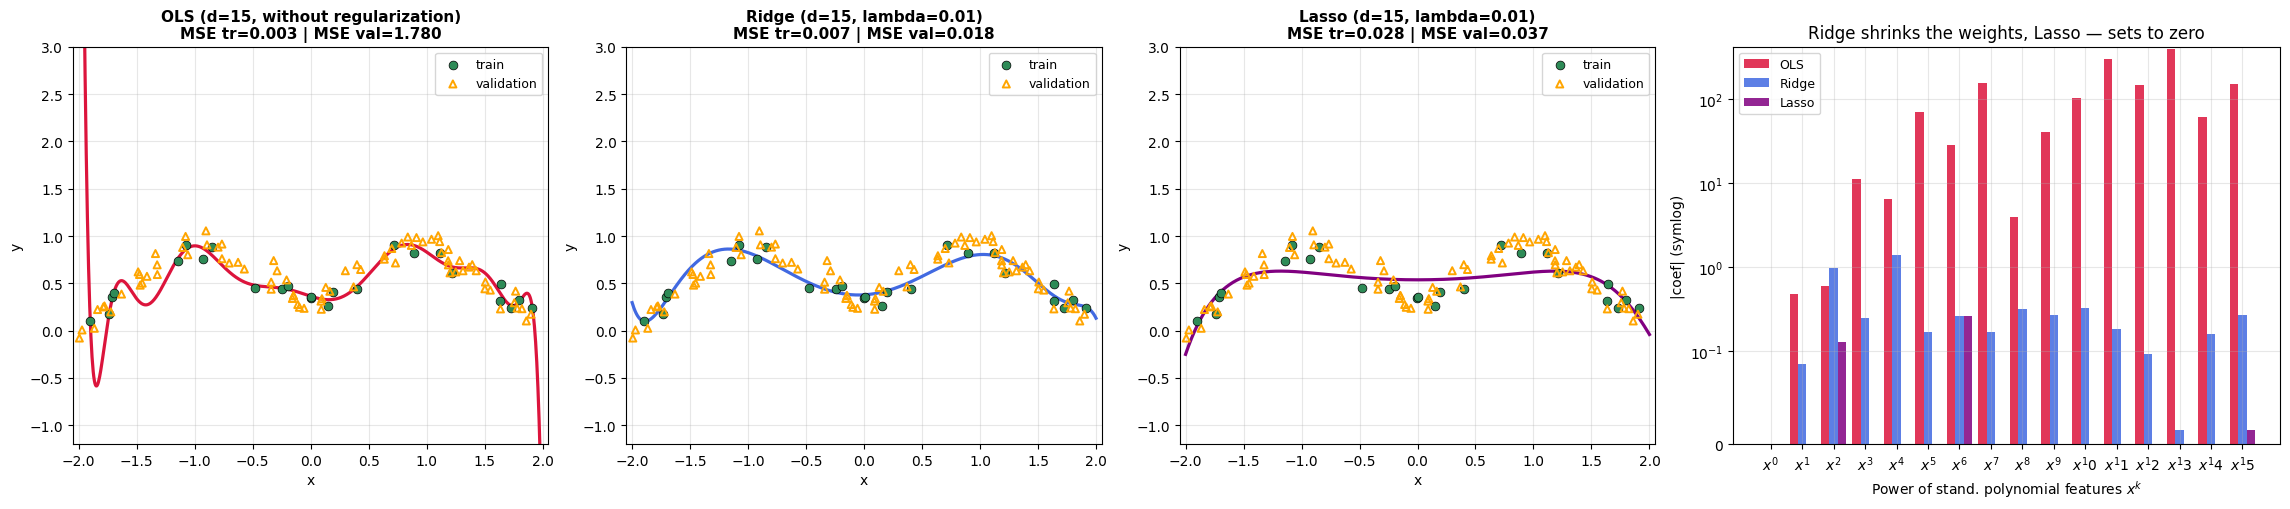

model      MSE tr  MSE val  #nonzero coef
OLS         0.003    1.780             15
Ridge       0.007    0.018             15
Lasso       0.028    0.037              3


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

np.random.seed(7)
C_TRAIN, C_VAL = "seagreen", "orange"

def m_shape(t):
    return np.piecewise(
        t,
        [t < -1, (t >= -1) & (t < 0), (t >= 0) & (t < 1), t >= 1],
        [lambda s: s + 2, lambda s: -0.7*s + 0.3,
         lambda s: 0.7*s + 0.3, lambda s: -s + 2])

n_train, n_val = 25, 80
X_tr  = np.sort(np.random.uniform(-2, 2, n_train))
y_tr  = m_shape(X_tr)  + np.random.normal(0, 0.08, n_train)
X_val = np.sort(np.random.uniform(-2, 2, n_val))
y_val = m_shape(X_val) + np.random.normal(0, 0.08, n_val)
X_tr_c, X_val_c = X_tr.reshape(-1, 1), X_val.reshape(-1, 1)

DEGREE = 15
grid = np.linspace(-2, 2, 800).reshape(-1, 1)


alphas = np.logspace(-2, 2.5, 30)
def best_alpha(cls):
    mses = [mean_squared_error(
                y_val,
                make_pipeline(PolynomialFeatures(DEGREE), StandardScaler(),
                              cls(alpha=a, max_iter=20000))
                .fit(X_tr_c, y_tr).predict(X_val_c))
            for a in alphas]
    return alphas[int(np.argmin(mses))]

a_ridge, a_lasso = best_alpha(Ridge), best_alpha(Lasso)
print(f"lambda* Ridge = {a_ridge:.3f} | lambda* Lasso = {a_lasso:.3f}")


models = {
    "OLS":  make_pipeline(PolynomialFeatures(DEGREE), StandardScaler(), LinearRegression()),
    "Ridge": make_pipeline(PolynomialFeatures(DEGREE), StandardScaler(), Ridge(alpha=a_ridge, max_iter=20000)),
    "Lasso": make_pipeline(PolynomialFeatures(DEGREE), StandardScaler(), Lasso(alpha=a_lasso, max_iter=20000)),
}
curve_cols = {"OLS": "crimson", "Ridge": "royalblue", "Lasso": "purple"}

fig, axes = plt.subplots(1, 4, figsize=(23, 5.2),
                         gridspec_kw={"width_ratios": [1, 1, 1, 1.15]})

coefs = {}
for ax, (name, m) in zip(axes[:3], models.items()):
    m.fit(X_tr_c, y_tr)
    coefs[name] = m[-1].coef_
    ax.scatter(X_tr, y_tr, s=40, color=C_TRAIN, edgecolors="k", lw=.5, label="train", zorder=3)
    ax.scatter(X_val, y_val, s=26, marker="^", facecolors="none",
               edgecolors=C_VAL, lw=1.4, label="validation", zorder=3)
    ax.plot(grid, m.predict(grid), color=curve_cols[name], lw=2.3, zorder=2)
    ax.set_title(f"{name} (d={DEGREE}, lambda={m[-1].alpha:.2f})\n"
                 f"MSE tr={mean_squared_error(y_tr, m.predict(X_tr_c)):.3f} | "
                 f"MSE val={mean_squared_error(y_val, m.predict(X_val_c)):.3f}"
                 if name != "OLS" else
                 f"{name} (d={DEGREE}, without regularization)\n"
                 f"MSE tr={mean_squared_error(y_tr, m.predict(X_tr_c)):.3f} | "
                 f"MSE val={mean_squared_error(y_val, m.predict(X_val_c)):.3f}",
                 fontsize=11, fontweight="bold")
    ax.set_xlim(-2.05, 2.05); ax.set_ylim(-1.2, 3.0)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.grid(alpha=.3); ax.legend(fontsize=9)


ax = axes[3]
xpos, w = np.arange(0, DEGREE + 1), 0.27

for i, name in enumerate(models):
    ax.bar(xpos + (i - 1) * w, np.abs(coefs[name]), w,
           label=name, color=curve_cols[name], alpha=.85)

ax.set_xticks(xpos)
ax.set_xticklabels([r"$x^0$"] + [fr"$x^{k}$" for k in range(1, DEGREE + 1)])

ax.set_yscale("symlog", linthresh=0.1)

ax.set_xlabel("Power of stand. polynomial features $x^k$"); ax.set_ylabel("|coef| (symlog)")
ax.set_title("Ridge shrinks the weights, Lasso — sets to zero")
ax.grid(alpha=.3); ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"{'model':8s} {'MSE tr':>8s} {'MSE val':>8s} {'#nonzero coef':>14s}")
for name, m in models.items():
    print(f"{name:8s} {mean_squared_error(y_tr, m.predict(X_tr_c)):8.3f} "
          f"{mean_squared_error(y_val, m.predict(X_val_c)):8.3f} "
          f"{int((np.abs(m[-1].coef_) > 1e-6).sum()):14d}")

## Coefficient of determination $R^2$

$R^2$ tells us **how much of the spread of $y$ our model explains**, compared
with the simplest possible model that always predicts the mean $\bar{y}$.

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 -
\frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}$$

- $y_i$ — true value, $\hat{y}_i$ — the model's prediction, $\bar{y}$ — mean of all $y$;
- the top sum ($SS_{res}$) is how much **our model** misses;
- the bottom sum ($SS_{tot}$) is how much the **"predict the mean" model** misses.


| Value | Meaning |
|------ |---------|
| $R^2 = 1$   | perfect predictions |
| $R^2 = 0.8$ | the model explains 80% of the spread of $y$ |
| $R^2 = 0$   | no better than predicting the mean |
| $R^2 < 0$   | worse than the mean — something is wrong |


> On training data $R^2$ always grows when we add features, even useless ones.

## Generalized Linear Models (GLM)

Ordinary linear regression assumes $y$ can be any number. Real targets are often
different: **yes/no**, **counts** (0, 1, 2, ... ), or **only positive values** (price, waiting time).

GLM keeps the familiar linear part $w_0 + w_1x_1 + \dots + w_dx_d$ and adds just
two ingredients:

1. **a distribution for $y$** — Normal, Bernoulli (yes/no), Poisson (counts), ...
2. **a link function $g$** — converts the linear prediction into a value that
   makes sense for $y$:

$$g(\mathbb{E}[y]) = w_0 + w_1 x_1 + \dots + w_d x_d$$

For example, logistic regression squashes the linear prediction into a
probability between 0 and 1, and Poisson regression uses a log link so the
predicted count is always positive.

| Task | Distribution of $y$ | Link | Model name |
|---|---|---|---|
| any number | Normal | identity | linear regression |
| yes / no | Bernoulli | logit | logistic regression |
| counts | Poisson | log | Poisson regression |

So GLM is not a new trick but a **family**: our linear/polynomial regression is
just one member of it, and everything we learned: polynomial features,
regularization, validation works there too.

## Why We Can't Use Linear Regression for Classification Problems



Imagine you are trying to predict whether a student will **pass (1)** or **fail (0)** a test based on the number of hours they studied.

If you plot the data, you see a cluster of `0`s on the left (low hours) and a cluster of `1`s on the right (high hours). If you draw a linear regression line through this data, it looks correct

For perfectly clean data, this illusion holds up. But in the real world, using linear regression for classification breaks down for **three major reasons**.

### Problem 1: The Output Range Problem

#### Continuous vs. Discrete Outputs

**Linear Regression** is designed to predict *continuous* values:
$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_n x_n$$

The output $\hat{y}$ can be **any real number**: $-\infty < \hat{y} < +\infty$

**Classification** requires:
- **Discrete categories** (0 or 1)
- **Probabilities** strictly bounded: $0 \leq P(y=1|x) \leq 1$

### The Problem:
If linear regression predicts:
- $\hat{y} = 1.2$ → Probability of 120%?
- $\hat{y} = -0.5$ → Probability of -50%?

Linear regression has **no mechanism** to bound predictions between 0 and 1.

---

### Problem 2: The Outlier Problem (The Fatal Flaw)

### How Linear Regression Works

Linear regression uses **Ordinary Least Squares (OLS)**:
$$\min_{\beta} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

It minimizes the **sum of squared errors**, making it **highly sensitive to outliers**.

---

### Problem 3: Violation of Statistical Assumptions

Linear regression relies on critical assumptions that are **violated** in classification:

#### Assumption 1: Homoscedasticity (Constant Variance)

**Assumption:** $\text{Var}(\epsilon_i) = \sigma^2$ (constant for all $i$)

**Reality in Classification:**
For binary outcomes with probability $p$:
$$\text{Var}(Y) = p(1-p)$$

- When $p \approx 0$ or $p \approx 1$: Variance is **small** (near 0)
- When $p \approx 0.5$: Variance is **large** (maximum at 0.25)

This is **heteroscedasticity** - variance changes with $X$!

### Assumption 2: Normality of Errors

**Assumption:** $\epsilon_i \sim \mathcal{N}(0, \sigma^2)$

**Reality in Classification:**
- Actual values are only 0 or 1
- Errors can only take **two specific values**
- Error distribution is **Binomial**, not Normal!

#### Consequences:
- **Unreliable p-values** and confidence intervals
- **Invalid hypothesis tests**
- **Inefficient parameter estimates**

**Never use linear regression for classification!**

While it might seem to work on simple, clean datasets, it fundamentally violates the mathematical and statistical requirements of classification problems. Always use **logistic regression** (for binary classification) or other appropriate classification algorithms (softmax regression, decision trees, SVM, etc.) for categorical outcomes.

In [ ]:
import ipywidgets as widgets
from IPython.display import display

def plot_with_outlier_position(outlier_x=10, outlier_y=0):
    """Show how outlier position affects the decision boundary"""
    fig, ax = plt.subplots(figsize=(10, 6))

    # Base data
    X_base = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9]).reshape(-1, 1)
    y_base = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1])

    # Add outlier
    X_with_outlier = np.vstack([X_base, [outlier_x]])
    y_with_outlier = np.append(y_base, outlier_y)

    # Fit model
    lr = LinearRegression()
    lr.fit(X_with_outlier, y_with_outlier)

    # Predictions
    X_pred = np.linspace(0, 11, 100).reshape(-1, 1)
    y_pred = lr.predict(X_pred)

    # Decision boundary
    threshold = (0.5 - lr.intercept_) / lr.coef_[0]

    # Plot
    ax.scatter(X_base, y_base, c='blue', s=100, alpha=0.7, label='Regular Data')
    ax.scatter(outlier_x, outlier_y, c='red', s=200, marker='x', linewidth=3, label=f'Outlier at ({outlier_x}, {outlier_y})')
    ax.plot(X_pred, y_pred, 'k-', linewidth=2)
    ax.axvline(x=threshold, color='r', linestyle='--', linewidth=2, label=f'Decision Boundary: {threshold:.2f}h')
    ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=1)

    ax.set_xlabel('Hours Studied', fontsize=11)
    ax.set_ylabel('Prediction', fontsize=11)
    ax.set_title(f'Effect of Outlier Position on Decision Boundary', fontsize=12, fontweight='bold')
    ax.legend()
    ax.set_xlim(0, 11)
    ax.set_ylim(-0.2, 1.2)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Create interactive widgets
outlier_x_slider = widgets.FloatSlider(value=10.0, min=5.0, max=10.0, step=0.5, description='Outlier X:')
outlier_y_dropdown = widgets.Dropdown(options=[0, 1], value=0, description='Outlier Y:')

interactive_plot = widgets.interactive(plot_with_outlier_position,
                                        outlier_x=outlier_x_slider,
                                        outlier_y=outlier_y_dropdown)

display(interactive_plot)

interactive(children=(FloatSlider(value=10.0, description='Outlier X:', max=10.0, min=5.0, step=0.5), Dropdown…

## **Logistic Regression**

### From Linear to Logistic Regression

In **Linear Regression**, our model predicts a continuous output $\hat{y}$ by computing a linear combination of features. This output $z$ can take any value in the range $(-\infty, +\infty)$:
$$ z = \mathbf{w}^T \mathbf{x} + b $$

However, for **binary classification**, we don't want a continuous number; we need to predict the *probability* that an instance belongs to the positive class. Probabilities must be strictly bounded between $0$ and $1$.

### Why do we need the Sigmoid function?
To bridge this gap, we "squash" the unbounded linear output $z$ into the $(0, 1)$ interval using the **sigmoid (logistic) function**. The sigmoid acts as an activation function that transforms the raw linear score into a valid probability, making it interpretable and suitable for classification.

### Mathematical Formulation
The sigmoid function is defined as:
$$ \sigma(z) = \frac{1}{1 + e^{-z}} $$

By plugging our linear equation into the sigmoid, we get the **Logistic Regression** model:
$$ \hat{y} = P(y=1 | \mathbf{x}) = \sigma(\mathbf{w}^T \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^T \mathbf{x} + b)}} $$

Finally, to make a discrete class prediction, we apply a decision threshold (typically $0.5$):
$$ \hat{class} = \begin{cases} 1 & \text{if } \hat{y} \geq 0.5 \\ 0 & \text{if } \hat{y} < 0.5 \end{cases} $$

<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3373/1941139318.py:20: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sigma(z)$ (Probability)', fontsize=12)


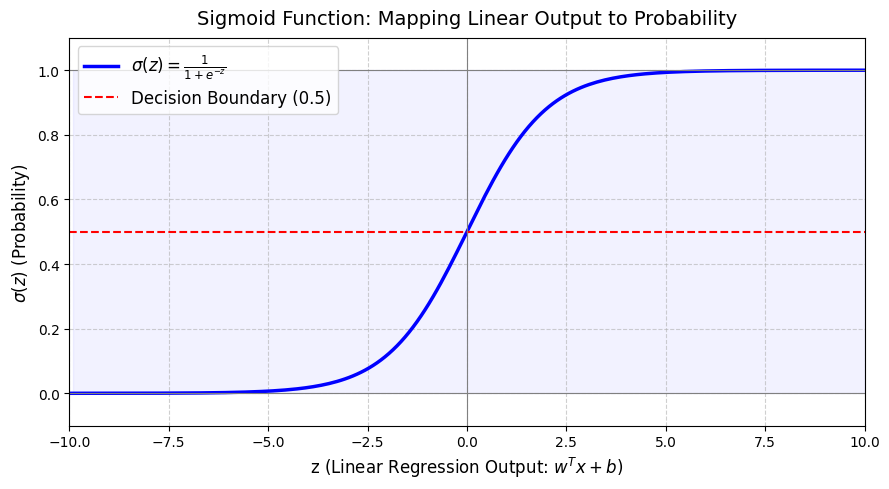

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 200)
y = sigmoid(z)

plt.figure(figsize=(9, 5))
plt.plot(z, y, color='blue', linewidth=2.5, label=r'$\sigma(z) = \frac{1}{1 + e^{-z}}$')

plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Decision Boundary (0.5)')
plt.axhline(y=0, color='gray', linestyle='-', linewidth=0.8)
plt.axhline(y=1, color='gray', linestyle='-', linewidth=0.8)
plt.axvline(x=0, color='gray', linestyle='-', linewidth=0.8)

plt.title('Sigmoid Function: Mapping Linear Output to Probability', fontsize=14, pad=10)
plt.xlabel('z (Linear Regression Output: $w^Tx + b$)', fontsize=12)
plt.ylabel('$\sigma(z)$ (Probability)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(-0.1, 1.1)
plt.xlim(-10, 10)

plt.fill_between(z, 0, 1, where=(z > -10), color='blue', alpha=0.05)

plt.tight_layout()
plt.show()

### Deriving the Loss Function for Logistic Regression




We derive the loss function using a probabilistic approach called **Maximum Likelihood Estimation (MLE)**.


**Step 1**: Define the Probability of a Single Observation
Our model outputs $\hat{y}$, which represents the estimated probability that $y=1$:

$$ \hat{y} = P(y=1 | \mathbf{x}) $$

Consequently, the probability that $y=0$ is:

$$ P(y=0 | \mathbf{x}) = 1 - \hat{y} $$

We can combine these two cases into a single mathematical expression for a single training example $(\mathbf{x}, y)$:

$$ P(y | \mathbf{x}) = \hat{y}^y (1 - \hat{y})^{1-y} $$


**Step 2**: The Likelihood of the Entire Dataset
Assuming our $n$ training examples are independent and identically distributed (i.i.d.), the likelihood of observing the entire dataset $Y$ given our parameters $\mathbf{w}$ and $b$ is the product of the individual probabilities:
$$ L(\mathbf{w}, b) = \prod_{i=1}^{n} P(y_i | \mathbf{x}_i) = \prod_{i=1}^{n} \hat{y}_i^{y_i} (1 - \hat{y}_i)^{1-y_i} $$
Our goal in MLE is to find the parameters $\mathbf{w}, b$ that **maximize** this likelihood $L$.

**Step 3**: The Log-Likelihood
Maximizing a product of many small probabilities is computationally difficult. To fix this, we take the natural logarithm of the likelihood function. Because $\log$ is a monotonically increasing function, maximizing the log-likelihood is mathematically equivalent to **maximizing** the likelihood:
$$ \ell(\mathbf{w}, b) = \log L(\mathbf{w}, b) = \sum_{i=1}^{n} \Big[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \Big] $$
Now, the product has turned into a much easier-to-handle sum.

**Step 4**: The Loss Function (Negative Log-Likelihood)
Standard optimization algorithms (like Gradient Descent) are designed to **minimize** a cost function, not maximize it. Therefore, we simply negate the log-likelihood. We also divide by $n$ to compute the *average* loss per sample, making it independent of the dataset size.

This gives us the final **Binary Cross-Entropy Loss** (also known as Log Loss):
$$ J(\mathbf{w}, b) = -\frac{1}{n} \sum_{i=1}^{n} \Big[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \Big] $$


**Summary of the Final Loss Function**
For a single example, the loss is:
$$ \mathcal{L}(\hat{y}, y) = \begin{cases} -\log(\hat{y}) & \text{if } y = 1 \\ -\log(1 - \hat{y}) & \text{if } y = 0 \end{cases} $$

**Explanation:**
* If the true label is $y=1$ and our model predicts $\hat{y} \approx 1$, the loss is $-\log(1) \approx 0$ (low penalty).
* If the true label is $y=1$ but our model predicts $\hat{y} \approx 0$, the loss is $-\log(0) \to \infty$ (huge penalty).

### Deriving the Gradient for Logistic Regression

To use Gradient Descent, we need to calculate the partial derivatives of our cost function $J$ with respect to our weights $\mathbf{w}$ and bias $b$.

Because our model is a composition of functions (Linear $\rightarrow$ Sigmoid $\rightarrow$ Log Loss), we must use the **Chain Rule**. To keep the math clean, let's first find the gradient for a **single training example** $(\mathbf{x}, y)$, and then we will average it for the whole dataset at the end.

Let's define our intermediate variables:
1. Linear output: $z = \mathbf{w}^T \mathbf{x} + b$
2. Prediction (Sigmoid): $\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}$
3. Single-example Loss: $\mathcal{L} = - \left[ y \log(\hat{y}) + (1 - y) \log(1 - \hat{y}) \right]$

We need to find $\frac{\partial \mathcal{L}}{\partial \mathbf{w}}$. By the Chain Rule:
$$ \frac{\partial \mathcal{L}}{\partial \mathbf{w}} = \frac{\partial \mathcal{L}}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial \mathbf{w}} $$


#### Final Gradients for the Dataset
To get the gradient for the entire cost function $J$, we just average these single-example gradients over all $n$ training examples:

$$ \frac{\partial J}{\partial \mathbf{w}} = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i) \mathbf{x}_i $$
$$ \frac{\partial J}{\partial b} = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i) $$

**In Vectorized Form (for Python/NumPy):**
If $\mathbf{X}$ is our matrix of features (shape $n \times d$), $\hat{\mathbf{y}}$ is our vector of predictions, and $\mathbf{y}$ is our vector of true labels, we can compute the gradients in a single, highly efficient line of code:
$$ \nabla_{\mathbf{w}} J = \frac{1}{n} \mathbf{X}^T (\hat{\mathbf{y}} - \mathbf{y}) $$
$$ \nabla_{b} J = \frac{1}{n} \sum (\hat{\mathbf{y}} - \mathbf{y}) $$


Accuracy: 1.0000
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



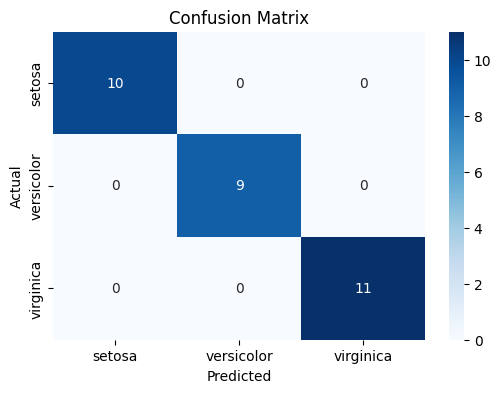

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=200, random_state=42)
)

model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### The Link Between Logistic Regression and Neural Networks

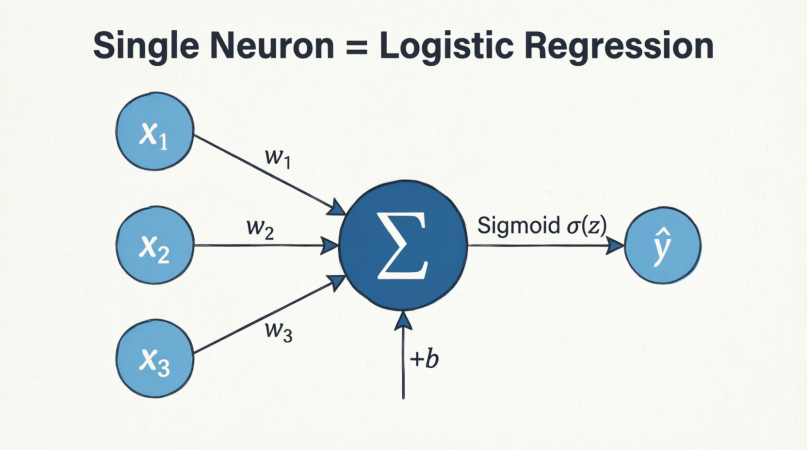


**A single artificial neuron with a sigmoid activation function is mathematically identical to Logistic Regression.**

Logistic Regression equation:

$$\hat{y} = \sigma(\mathbf{w}^T \mathbf{x} + b).$$

 1. The Inputs and Weights
In a neural network, a neuron receives signals from the outside world (or from previous neurons). These are our features $\mathbf{x} = [x_1, x_2, ..., x_d]$.
Each input is multiplied by a **weight** $w_i$, which represents the "strength" or "importance" of that specific input signal.

 2. The Summation and Bias
The neuron aggregates all these weighted signals. It sums them up and adds a **bias** term $b$. The bias allows the neuron to shift its activation threshold to the left or right, independent of the inputs.

$$ z = \sum_{i=1}^{d} w_i x_i + b = \mathbf{w}^T \mathbf{x} + b $$

 3. The Activation Function
In biology, a neuron only "fires" (sends an electrical spike) if the accumulated signal crosses a certain threshold. In artificial neural networks, we model this using an **activation function**.
For binary classification, we use the **Sigmoid function** $\sigma(z)$, which squashes the aggregated signal $z$ into a probability between 0 and 1.

$$ \hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}} $$

4. The Output
The final result $\hat{y}$ is passed forward. In a single-neuron network, this is our final prediction.


To extend Logistic Regression to multi-class classification, we typically use one of two strategies:
**One-vs-Rest (OvR)** or **Multinomial (Softmax) Regression**.

1. In the **OvR** approach, we train $K$ separate binary logistic regression models (one for each of the $K$ classes), where each model learns to distinguish its specific class from all others combined, and the final prediction is simply the class with the highest predicted probability.
2. In **Multinomial Logistic Regression**, we replace the single Sigmoid neuron with $K$ parallel output neurons and change the Sigmoid function to the **Softmax function**, which normalizes the raw linear outputs into a unified probability distribution that sums to 1.

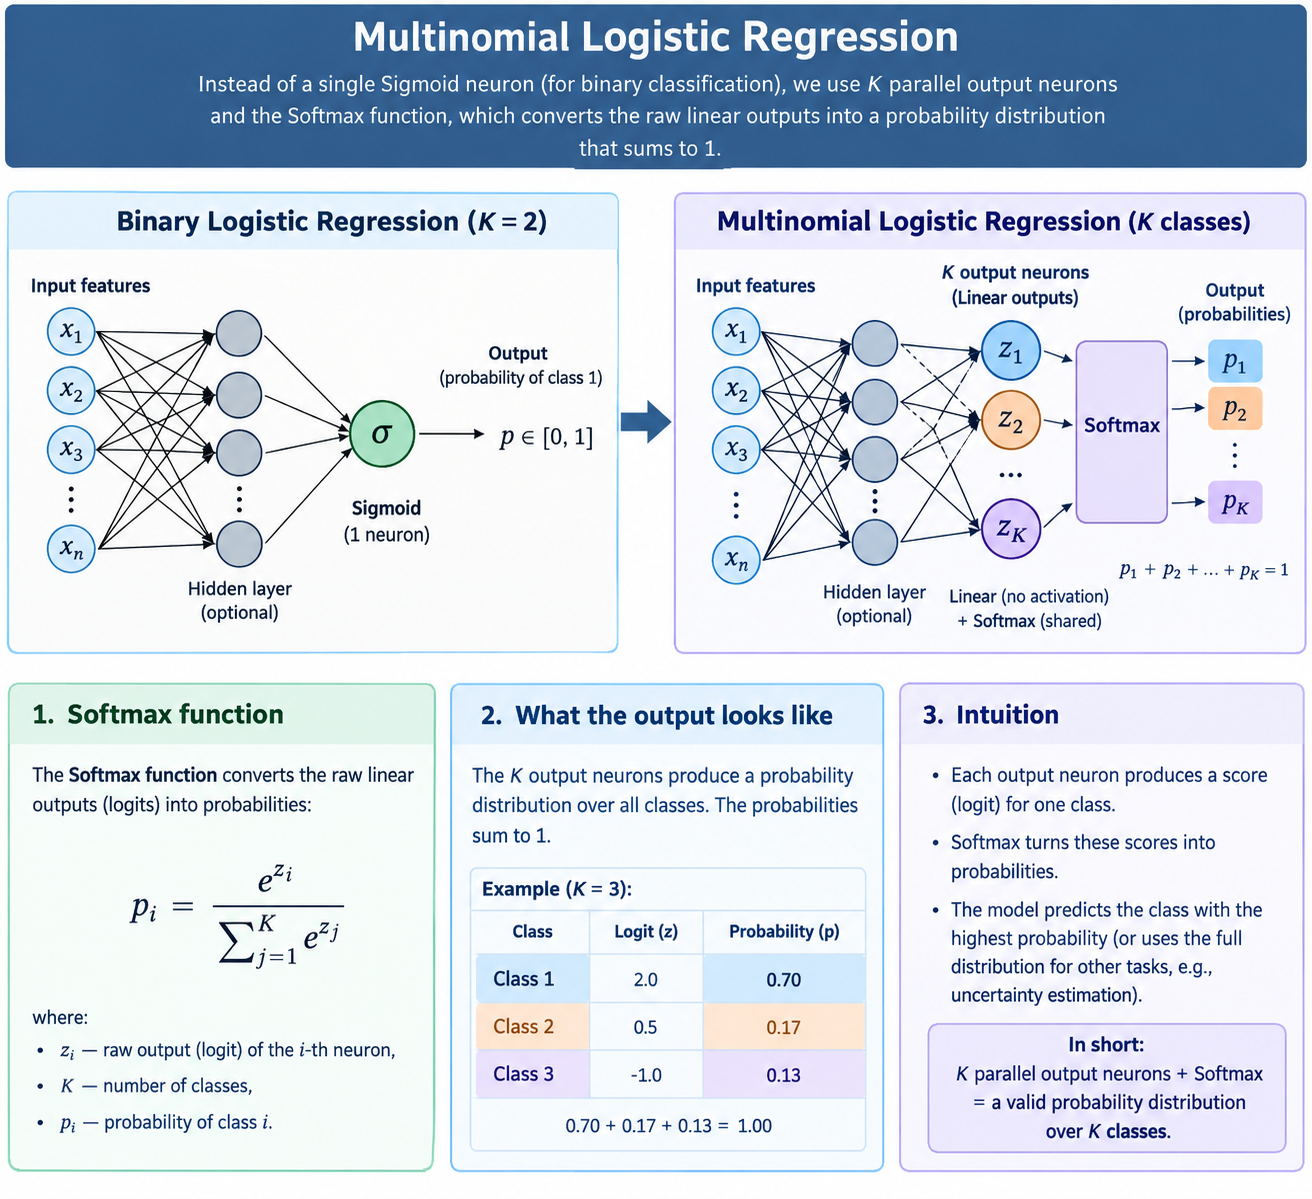

###Practical Insights for Logistic Regression

While neural networks are "black boxes", Logistic Regression is a **white box**. Its greatest advantage is **interpretability**.

#### The Odds Ratio
The weights $\mathbf{w}$ in Logistic Regression are not just arbitrary numbers; they have a direct, real-world meaning. To understand this, we need to look at the **Log-Odds** (also called the Logit function).

We can easily derive this by reversing the Sigmoid function we learned earlier. Predicted probability is $p = \hat{y} = \frac{1}{1 + e^{-z}}$, where $z = \mathbf{w}^T \mathbf{x} + b$. Let's find the ratio of the probability of class 1 (**Yes**) ($p$) to the probability of class 0 (**No**) ($1-p$):

$$ 1 - p = 1 - \frac{1}{1 + e^{-z}} = \frac{e^{-z}}{1 + e^{-z}} $$

$$ \frac{p}{1 - p} = \frac{\frac{1}{1 + e^{-z}}}{\frac{e^{-z}}{1 + e^{-z}}} = \frac{1}{e^{-z}} = e^z $$

**The First task for practical assignment!** ***If p=1, then we get zero division! Explain this problem.***

Taking the natural logarithm ($\ln$) of both sides gives us a linear relationship:

$$ \ln\left(\frac{p}{1-p}\right) = \ln(e^z) = z = \mathbf{w}^T \mathbf{x} + b $$

This proves that Logistic Regression is actually a **linear model for the log-odds**!

Now, if we look at a single weight $w_j$ in this equation, we can define the **Odds Ratio**:

$$ \text{Odds Ratio} = e^{w_j} $$

**The Second task for practical assignment!** ***Prove this equation*!**

**Interpretation:** For every 1-unit increase in feature $x_j$ (holding all other features constant), the *odds* of the positive class ($y=1$) are multiplied by $e^{w_j}$.
*Example:* If $w_{\text{smoking}} = 0.69$, then $e^{0.69} \approx 2$. This means smoking doubles the odds of the disease. For negative class ($y=0$), $e^{-0.69} \approx 0.5$.

## Resources

1. StatQuest on Logistic Regression: https://youtube.com/playlist?list=PLblh5JKOoLUKxzEP5HA2d-Li7IJkHfXSe&si=Fvxf4TvWCogMWCSs

2. https://www.statlearning.com/

3. David W. Hosmer Jr., Stanley Lemeshow, Rodney X. Sturdivant. Applied Logistic Regression. 2013.

4. Xing Liu. Applied Ordinal Logistic Regression Using Stata: From Single-Level to Multilevel Modeling. 2015

5. https://machinelearningmastery.com/
